In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil
import pickle

In [2]:

project = 'SurvSurfBenchmark_NCT00981058_inject'
ds_name = 'real_NCT00981058_inject'
ds_df_dir = '/home/yc366/repos/survsurf_benchmark/dataset_split'
g_resol = 1
t_resol = 7
model_prefix = 'Joint'

DIR_MODEL_SAVE = os.path.join('sksurv_models', project, model_prefix)

if os.path.exists(DIR_MODEL_SAVE):
    shutil.rmtree(DIR_MODEL_SAVE)
    os.mkdir(DIR_MODEL_SAVE)
else:
    os.mkdir(DIR_MODEL_SAVE)

In [3]:
from dataset_NCT00981058 import DatasetNCT00981058

ds_train = DatasetNCT00981058(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    t_resol=t_resol,
    split='train', 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False
)
ds_val = DatasetNCT00981058(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    t_resol=t_resol,
    split='val', 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False
)


In [4]:
df_Xy_train = ds_train._get_df_Xy_trans_obs()
assert all(
    df_Xy_train.groupby(ds_train.colname_g)['subject'].apply(lambda x: x.value_counts().max() == 1)
)
df_Xy_train['event_observed'] = df_Xy_train['event_observed'].astype(bool)
df_Xy_train = df_Xy_train.sort_values('subject')

df_Xy_val = ds_val._get_df_Xy_trans_obs()
assert all(
    df_Xy_val.groupby(ds_train.colname_g)['subject'].apply(lambda x: x.value_counts().max() == 1)
)
df_Xy_val = df_Xy_val.sort_values('subject')
df_Xy_val['event_observed'] = df_Xy_val['event_observed'].astype(bool)

df_Xy_val_grid = ds_val._get_df_Xy_true_prob()
df_Xy_val_grid = df_Xy_val_grid.sort_values(['subject',ds_train.colname_g])
df_Xy_val_grid['event_observed'] = df_Xy_val_grid['event_observed'].astype(bool)


In [5]:
df_Xy_train.head()

,subject,event_observed,duration,g_max_by_time,feat__AGE,feat__BLOOD AND LYMPHATIC SYSTEM DISORDERS,feat__BMIBL,feat__BSABL,feat__Body Surface Area (m^2),feat__CARDIAC DISORDERS,...,feat__SOCIAL CIRCUMSTANCES,feat__SURGICAL AND MEDICAL PROCEDURES,feat__Systolic Blood Pressure (mmHg),feat__Temperature (°C),feat__VASCULAR DISORDERS,"feat__WBCCAT1_> 11,000 µl (11 x 10^9/L)",feat__Weight (kg),feat__traj_clust,weight,is_t_trans
0,b'001-7882',True,2.0,2.0,-0.712101,0.666667,-0.911691,0.110984,0.110984,0.0,...,0.0,0.666667,-1.685565,-0.746404,0.0,0.0,-0.381528,0.25,1,1
1,b'001-7882',True,15.0,4.0,-0.712101,0.666667,-0.911691,0.110984,0.110984,0.0,...,0.0,0.666667,-1.685565,-0.746404,0.0,0.0,-0.381528,0.25,1,1
2,b'001-7882',False,126.0,5.0,-0.712101,0.666667,-0.911691,0.110984,0.110984,0.0,...,0.0,0.666667,-1.685565,-0.746404,0.0,0.0,-0.381528,0.25,1,1
3,b'008-7881',True,4.0,1.0,-0.347338,0.000000,0.000045,-0.032476,-0.032476,0.0,...,0.0,0.000000,-1.361689,-1.580505,0.0,1.0,-0.100561,0.50,1,1
4,b'008-7881',False,62.0,2.0,-0.347338,0.000000,0.000045,-0.032476,-0.032476,0.0,...,0.0,0.000000,-1.361689,-1.580505,0.0,1.0,-0.100561,0.50,1,1


In [6]:
cols_y = ['event_observed', 'duration']
cols_X = np.r_[[ds_train.colname_g], df_Xy_train.columns[df_Xy_train.columns.str.startswith('feat')]]

In [7]:
cols_y

['event_observed', 'duration']

In [8]:
cols_X

array(['g_max_by_time', 'feat__AGE',
       'feat__BLOOD AND LYMPHATIC SYSTEM DISORDERS', 'feat__BMIBL',
       'feat__BSABL', 'feat__Body Surface Area (m^2)',
       'feat__CARDIAC DISORDERS',
       'feat__CONGENITAL, FAMILIAL AND GENETIC DISORDERS',
       'feat__Diastolic Blood Pressure (mmHg)',
       'feat__EAR AND LABYRINTH DISORDERS', 'feat__ECOGBL',
       'feat__ENDOCRINE DISORDERS', 'feat__ETHNIC_merged_cat',
       'feat__EYE DISORDERS', 'feat__GASTROINTESTINAL DISORDERS',
       'feat__GENERAL DISORDERS AND ADMINISTRATION SITE CONDITIONS',
       'feat__HEPATOBILIARY DISORDERS', 'feat__HGBCAT1_>= 11.5 g/dL',
       'feat__HISTOLG_Other', 'feat__HISTOLG_Papillary',
       'feat__HISTOLG_Small cell', 'feat__HISTOLG_merged_cat',
       'feat__Height (cm)', 'feat__IMMUNE SYSTEM DISORDERS',
       'feat__INFECTIONS AND INFESTATIONS',
       'feat__INJURY, POISONING AND PROCEDURAL COMPLICATIONS',
       'feat__INVESTIGATIONS', 'feat__METABOLISM AND NUTRITION DISORDERS',
       '

In [9]:
from sksurv.ensemble import GradientBoostingSurvivalAnalysis, RandomSurvivalForest
from sksurv.linear_model import CoxnetSurvivalAnalysis, CoxPHSurvivalAnalysis
def get_non_cox_model(model_class):
    def get_model(n_jobs, random_state):
        try:
            return model_class(n_jobs=n_jobs, random_state=random_state, min_samples_leaf=3, n_estimators=1000)
        except TypeError:
            return model_class(random_state=random_state, min_samples_leaf=20, n_estimators=50)
    return get_model

def get_cox_model(model_class):
    def get_model(n_jobs, random_state):
        try:
            return model_class(fit_baseline_model=True, n_jobs=n_jobs)
        except TypeError:
            try:
                return model_class(fit_baseline_model=True)
            except TypeError:
                return model_class()
    return get_model

model_name_to_class = {
    f'{model_prefix}_{GradientBoostingSurvivalAnalysis.__name__}':get_non_cox_model(GradientBoostingSurvivalAnalysis),
    f'{model_prefix}_{RandomSurvivalForest.__name__}':get_non_cox_model(RandomSurvivalForest),
    f'{model_prefix}_{CoxnetSurvivalAnalysis.__name__}':get_cox_model(CoxnetSurvivalAnalysis),
    f'{model_prefix}_{CoxPHSurvivalAnalysis.__name__}':get_cox_model(CoxPHSurvivalAnalysis),
}

In [10]:
df_metrics = []
surv_funcs = dict()
event_to_model = dict()
seeds = [10,20,30,40,50]
for model_name, model_class in model_name_to_class.items():
    for seed in seeds:
        model_id = f'{model_name}_seed_{seed}'
        model = model_class(n_jobs=-1, random_state=seed)
        y = df_Xy_train[cols_y].to_records(index=False)
        X = df_Xy_train[cols_X]
        model.fit(X, y)

        model_path = os.path.join(DIR_MODEL_SAVE,f'{model_id}.pickle')
        with open(model_path, 'wb') as f:
            # Pickle the 'data' dictionary using the highest protocol available.
            pickle.dump(model, f)

        for g, df_train_sub in df_Xy_train.groupby(ds_train.colname_g):
            if all(df_train_sub['event_observed'] == 0):
                continue
            
            y = df_train_sub[cols_y].to_records(index=False)
            X = df_train_sub[cols_X]
            event_to_model[f'{model_id}_event_{g}'] = model
            record = {
                'model_name':model_name,
                'event':g,
                'seed':seed,
                'c_index_train':model.score(X,y)
            }

            df_val_sub = df_Xy_val.loc[
                df_Xy_val[ds_train.colname_g] == g,:
            ]
            y = df_val_sub[cols_y].to_records(index=False)
            X = df_val_sub[cols_X]
            record['c_index_val'] = model.score(X,y)
            df_metrics.append(record)

            df_val_sub = df_Xy_val_grid.loc[
                df_Xy_val_grid[ds_train.colname_g] == g,:
            ].drop(columns=['duration','event_observed']).drop_duplicates().sort_values('subject')
            X = df_val_sub[cols_X]

            surv_funcs[f'{model_id}_event_{g}'] = model.predict_survival_function(X=X)
        print(f'finished running model {model_name}')
df_metrics = pd.DataFrame(df_metrics)


finished running model Joint_GradientBoostingSurvivalAnalysis
finished running model Joint_GradientBoostingSurvivalAnalysis
finished running model Joint_GradientBoostingSurvivalAnalysis
finished running model Joint_GradientBoostingSurvivalAnalysis
finished running model Joint_GradientBoostingSurvivalAnalysis
finished running model Joint_RandomSurvivalForest
finished running model Joint_RandomSurvivalForest
finished running model Joint_RandomSurvivalForest
finished running model Joint_RandomSurvivalForest
finished running model Joint_RandomSurvivalForest
finished running model Joint_CoxnetSurvivalAnalysis
finished running model Joint_CoxnetSurvivalAnalysis
finished running model Joint_CoxnetSurvivalAnalysis
finished running model Joint_CoxnetSurvivalAnalysis
finished running model Joint_CoxnetSurvivalAnalysis


/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=6.28232e-32): result may not be accurate.
  delta = solve(
/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=1.2162e-34): result may not be accurate.
  delta = solve(
/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=1.14424e-33): result may not be accurate.
  delta = solve(
/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=1.23037e-33): result may not be accurate.
  delta = solve(
/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: 

finished running model Joint_CoxPHSurvivalAnalysis


/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=6.28232e-32): result may not be accurate.
  delta = solve(
/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=1.2162e-34): result may not be accurate.
  delta = solve(
/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=1.14424e-33): result may not be accurate.
  delta = solve(
/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=1.23037e-33): result may not be accurate.
  delta = solve(
/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: 

finished running model Joint_CoxPHSurvivalAnalysis


...

/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=1.2162e-34): result may not be accurate.
  delta = solve(
/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=1.14424e-33): result may not be accurate.
  delta = solve(
/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=1.23037e-33): result may not be accurate.
  delta = solve(
/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=1.44247e-34): result may not be accurate.
  delta = solve(
/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: 

finished running model Joint_CoxPHSurvivalAnalysis


/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=1.23037e-33): result may not be accurate.
  delta = solve(
/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=1.44247e-34): result may not be accurate.
  delta = solve(
/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=3.37037e-32): result may not be accurate.
  delta = solve(
/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=2.10592e-32): result may not be accurate.
  delta = solve(
/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning:

finished running model Joint_CoxPHSurvivalAnalysis


/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=9.60492e-35): result may not be accurate.
  delta = solve(
/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=1.5282e-33): result may not be accurate.
  delta = solve(
/tmp/ipykernel_6089/2753664329.py:11: ConvergenceWarning: Optimization did not converge: Maximum number of iterations has been exceeded.
  model.fit(X, y)


In [11]:
df_train_sub

,subject,event_observed,duration,g_max_by_time,feat__AGE,feat__BLOOD AND LYMPHATIC SYSTEM DISORDERS,feat__BMIBL,feat__BSABL,feat__Body Surface Area (m^2),feat__CARDIAC DISORDERS,...,feat__SOCIAL CIRCUMSTANCES,feat__SURGICAL AND MEDICAL PROCEDURES,feat__Systolic Blood Pressure (mmHg),feat__Temperature (°C),feat__VASCULAR DISORDERS,"feat__WBCCAT1_> 11,000 µl (11 x 10^9/L)",feat__Weight (kg),feat__traj_clust,weight,is_t_trans
97,b'043-7882',False,26.0,6.0,0.139011,0.0,-0.702735,0.110984,0.110984,0.5,...,0.0,0.000000,-0.390063,-0.954929,1.000000,0.0,-0.287872,0.00,1,1
214,b'075-7886',False,12.0,6.0,0.990123,0.0,-1.609353,-0.988875,-0.988875,0.0,...,0.0,0.333333,0.905439,-1.371980,0.000000,0.0,-1.224431,0.00,1,1
601,b'583-7886',False,77.0,6.0,-1.198450,0.0,-0.903033,-0.749775,-0.749775,0.0,...,0.0,0.000000,0.322463,-0.954929,0.000000,0.0,-0.831076,0.00,1,1
636,b'639-7880',False,115.0,6.0,-0.833688,0.0,0.941570,1.306483,1.306483,0.5,...,0.0,0.000000,0.387238,-0.329353,0.000000,1.0,1.210621,0.75,1,1
735,b'660-7881',False,59.0,6.0,0.625361,0.0,-1.524835,-1.419255,-1.419255,0.0,...,0.0,0.000000,-0.390063,0.087698,0.000000,1.0,-1.442961,0.00,1,1
753,b'665-7808',False,16.0,6.0,0.382186,0.0,-0.456495,-0.749775,-0.749775,0.5,...,0.0,0.333333,-2.333316,-1.371980,0.333333,1.0,-0.724933,0.00,1,1


In [12]:
df_metrics.groupby(['model_name','event'])['c_index_val'].describe()

count      mean           std  \
model_name                             event                                  
Joint_CoxPHSurvivalAnalysis            1.0      5.0  0.619916  0.000000e+00   
                                       2.0      5.0  0.653817  0.000000e+00   
                                       3.0      5.0  0.754967  0.000000e+00   
                                       4.0      5.0  0.679191  0.000000e+00   
                                       5.0      5.0  0.625000  0.000000e+00   
Joint_CoxnetSurvivalAnalysis           1.0      5.0  0.624123  0.000000e+00   
                                       2.0      5.0  0.653817  0.000000e+00   
                                       3.0      5.0  0.753642  0.000000e+00   
                                       4.0      5.0  0.682081  0.000000e+00   
                                       5.0      5.0  0.625000  0.000000e+00   
Joint_GradientBoostingSurvivalAnalysis 1.0      5.0  0.598527  0.000000e+00   
                                       2.0      5.0  0.627740  0.000000e+00   
                                       3.0      5.0  0.803642  1.241267e-16   
                                       4.0      5.0  0.634393  0.000000e+00   
                                       5.0      5.0  0.916667  0.000000e+00   
Joint_RandomSurvivalForest             1.0      5.0  0.608555  1.022738e-02   
                                       2.0      5.0  0.643764  6.920332e-03   
                                       3.0      5.0  0.744768  5.532874e-03   
                                       4.0      5.0  0.673988  1.750882e-02   
                                       5.0      5.0  0.750000  2.946278e-02   

                                                   min       25%       50%  \
model_name                             event                                 
Joint_CoxPHSurvivalAnalysis            1.0    0.619916  0.619916  0.619916   
                                       2.0    0.653817  0.653817  0.653817   
                                       3.0    0.754967  0.754967  0.754967   
                                       4.0    0.679191  0.679191  0.679191   
                                       5.0    0.625000  0.625000  0.625000   
Joint_CoxnetSurvivalAnalysis           1.0    0.624123  0.624123  0.624123   
                                       2.0    0.653817  0.653817  0.653817   
                                       3.0    0.753642  0.753642  0.753642   
                                       4.0    0.682081  0.682081  0.682081   
                                       5.0    0.625000  0.625000  0.625000   
Joint_GradientBoostingSurvivalAnalysis 1.0    0.598527  0.598527  0.598527   
                                       2.0    0.627740  0.627740  0.627740   
                                       3.0    0.803642  0.803642  0.803642   
                                       4.0    0.634393  0.634393  0.634393   
                                       5.0    0.916667  0.916667  0.916667   
Joint_RandomSurvivalForest             1.0    0.596073  0.600982  0.609397   
                                       2.0    0.636054  0.636432  0.647392   
                                       3.0    0.735099  0.745695  0.746358   
                                       4.0    0.647399  0.667630  0.679191   
                                       5.0    0.708333  0.750000  0.750000   

                                                   75%       max  
model_name                             event                      
Joint_CoxPHSurvivalAnalysis            1.0    0.619916  0.619916  
                                       2.0    0.653817  0.653817  
                                       3.0    0.754967  0.754967  
                                       4.0    0.679191  0.679191  
                                       5.0    0.625000  0.625000  
Joint_CoxnetSurvivalAnalysis           1.0    0.624123  0.624123  
                                       2.0    0.653817

In [13]:
df = df_metrics.copy()
df['val_as_frac_of_train'] = df_metrics['c_index_val']/df_metrics['c_index_train']
df.groupby(['model_name','event'])['val_as_frac_of_train'].describe()

count      mean           std  \
model_name                             event                                  
Joint_CoxPHSurvivalAnalysis            1.0      5.0  0.894192  0.000000e+00   
                                       2.0      5.0  0.926491  0.000000e+00   
                                       3.0      5.0  1.027550  0.000000e+00   
                                       4.0      5.0  0.993670  0.000000e+00   
                                       5.0      5.0  0.846631  0.000000e+00   
Joint_CoxnetSurvivalAnalysis           1.0      5.0  0.898462  0.000000e+00   
                                       2.0      5.0  0.927444  0.000000e+00   
                                       3.0      5.0  1.021359  0.000000e+00   
                                       4.0      5.0  0.996185  1.241267e-16   
                                       5.0      5.0  0.846631  0.000000e+00   
Joint_GradientBoostingSurvivalAnalysis 1.0      5.0  0.871556  1.241267e-16   
                                       2.0      5.0  0.904328  1.241267e-16   
                                       3.0      5.0  0.950300  1.241267e-16   
                                       4.0      5.0  0.822333  0.000000e+00   
                                       5.0      5.0  1.067581  0.000000e+00   
Joint_RandomSurvivalForest             1.0      5.0  0.781039  1.356600e-02   
                                       2.0      5.0  0.775072  7.870345e-03   
                                       3.0      5.0  0.809355  6.506214e-03   
                                       4.0      5.0  0.803740  2.056607e-02   
                                       5.0      5.0  0.933053  4.640618e-02   

                                                   min       25%       50%  \
model_name                             event                                 
Joint_CoxPHSurvivalAnalysis            1.0    0.894192  0.894192  0.894192   
                                       2.0    0.926491  0.926491  0.926491   
                                       3.0    1.027550  1.027550  1.027550   
                                       4.0    0.993670  0.993670  0.993670   
                                       5.0    0.846631  0.846631  0.846631   
Joint_CoxnetSurvivalAnalysis           1.0    0.898462  0.898462  0.898462   
                                       2.0    0.927444  0.927444  0.927444   
                                       3.0    1.021359  1.021359  1.021359   
                                       4.0    0.996185  0.996185  0.996185   
                                       5.0    0.846631  0.846631  0.846631   
Joint_GradientBoostingSurvivalAnalysis 1.0    0.871556  0.871556  0.871556   
                                       2.0    0.904328  0.904328  0.904328   
                                       3.0    0.950300  0.950300  0.950300   
                                       4.0    0.822333  0.822333  0.822333   
                                       5.0    1.067581  1.067581  1.067581   
Joint_RandomSurvivalForest             1.0    0.764737  0.772979  0.777999   
                                       2.0    0.765352  0.767733  0.779772   
                                       3.0    0.798129  0.809410  0.812283   
                                       4.0    0.772339  0.795359  0.809812   
                                       5.0    0.867254  0.918269  0.936275   

                                                   75%       max  
model_name                             event                      
Joint_CoxPHSurvivalAnalysis            1.0    0.894192  0.894192  
                                       2.0    0.926491  0.926491  
                                       3.0    1.027550  1.027550  
                                       4.0    0.993670  0.993670  
                                       5.0    0.846631  0.846631  
Joint_CoxnetSurvivalAnalysis           1.0    0.898462  0.898462  
                                       2.0    0.927444

([0, 1, 2, 3],
 [Text(0, 0, 'Joint_GradientBoostingSurvivalAnalysis'),
  Text(1, 0, 'Joint_RandomSurvivalForest'),
  Text(2, 0, 'Joint_CoxnetSurvivalAnalysis'),
  Text(3, 0, 'Joint_CoxPHSurvivalAnalysis')])

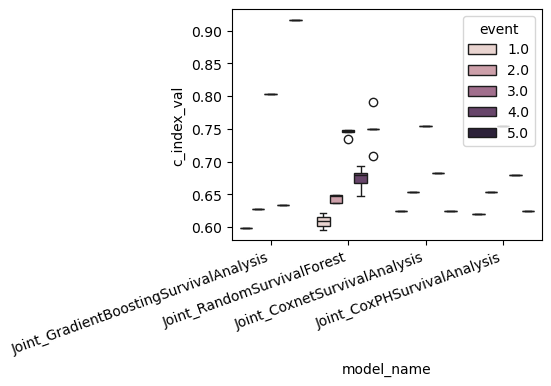

In [14]:
fig, ax = plt.subplots(1,1, figsize=(4, 3))
sns.boxplot(
    data=df_metrics,
    x='model_name',
    y='c_index_val',
    hue='event',
    ax=ax,
)
plt.xticks(rotation=20, ha='right')


In [15]:
n_curves_per_model = [len(i) for i in surv_funcs.values()]

n_curves_per_model = n_curves_per_model[0]

In [16]:
event_to_model.keys()

dict_keys(['Joint_GradientBoostingSurvivalAnalysis_seed_10_event_1.0', 'Joint_GradientBoostingSurvivalAnalysis_seed_10_event_2.0', 'Joint_GradientBoostingSurvivalAnalysis_seed_10_event_3.0', 'Joint_GradientBoostingSurvivalAnalysis_seed_10_event_4.0', 'Joint_GradientBoostingSurvivalAnalysis_seed_10_event_5.0', 'Joint_GradientBoostingSurvivalAnalysis_seed_20_event_1.0', 'Joint_GradientBoostingSurvivalAnalysis_seed_20_event_2.0', 'Joint_GradientBoostingSurvivalAnalysis_seed_20_event_3.0', 'Joint_GradientBoostingSurvivalAnalysis_seed_20_event_4.0', 'Joint_GradientBoostingSurvivalAnalysis_seed_20_event_5.0', 'Joint_GradientBoostingSurvivalAnalysis_seed_30_event_1.0', 'Joint_GradientBoostingSurvivalAnalysis_seed_30_event_2.0', 'Joint_GradientBoostingSurvivalAnalysis_seed_30_event_3.0', 'Joint_GradientBoostingSurvivalAnalysis_seed_30_event_4.0', 'Joint_GradientBoostingSurvivalAnalysis_seed_30_event_5.0', 'Joint_GradientBoostingSurvivalAnalysis_seed_40_event_1.0', 'Joint_GradientBoostingSurviv